In [ ]:
import logging
from pathlib import Path
from typing import Any, Callable, Sequence

import matplotlib.pyplot as plt
import mlflow
import nico2_lib as n2l
import numpy as np
import pandas as pd
import polars as pl
import scanpy as sc
import seaborn as sns
from experiment import Celltype, Dataset, Model, NumericArray, Result, Sample
from numpy import number
from sqlalchemy import event
from sqlalchemy.engine import Engine
from sqlmodel import Session, create_engine, select
from tqdm import tqdm

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

In [ ]:
DataEntries = list[dict[str, Any]]

In [ ]:
exp_name = "Default"
benchmark_experiment = mlflow.get_experiment_by_name(exp_name)
if not benchmark_experiment:
    raise ValueError(f"Experiment '{exp_name}' not found.")
runs = mlflow.search_runs(experiment_ids=[benchmark_experiment.experiment_id])
if runs.empty:
    raise RuntimeError(f"No runs found in experiment '{exp_name}'.")
last_run_id = runs.sort_values("start_time", ascending=False)["run_id"].iloc[0]
logger.info(f"Using run_id: {last_run_id}")
logger.info("Downloading 'database.db'...")
database_path = mlflow.artifacts.download_artifacts(
    run_id=last_run_id, artifact_path="database.db"
)
logger.info(f"Local path: {database_path}")
sqlite_url = f"sqlite:///{database_path}"
engine = create_engine(sqlite_url, echo=True)
logger.info("Database engine initialized.")

In [ ]:
database_path = "/Users/egerc/Documents/Projects/notebook_repository/notebooks/2026-02-27T09-05-08Z/database.db"
logger.info(f"Local path: {database_path}")
sqlite_url = f"sqlite:///{database_path}"
engine = create_engine(sqlite_url, echo=True)
logger.info("Database engine initialized.")

In [ ]:
import re


def sanitize_filename(name: str) -> str:
    return re.sub(r'[/\\?%*:|"<>]', "_", name)


In [ ]:
import matplotlib.pyplot as plt


def plot_embedding(
    results: Sequence[tuple[Result, Model]], celltype: Celltype, sample: Sample
) -> None:
    n_rows = len(results)
    max_latents = max(r.celltype_model_embedding_query.shape[1] for r, _ in results)

    # Create the figure with subfigures for each latent dimension
    fig = plt.figure(figsize=(max_latents * 4, n_rows * 3), dpi=300)
    subfigs = fig.subfigures(n_rows, max_latents, wspace=0.1, hspace=0.1)

    query_umap = celltype.query_umap_embedding
    reference_umap = celltype.reference_umap_embedding

    for r_idx, (res, model) in enumerate(results):
        q_latents = res.celltype_model_embedding_query
        r_latents = res.celltype_model_embedding_reference
        k_current = q_latents.shape[1]

        for latent_idx in range(max_latents):
            subfig = subfigs[r_idx, latent_idx]

            # Style the subfigure container
            subfig.set_facecolor("#fcfcfc")
            subfig.suptitle(f"Latent {latent_idx}", fontsize=10, fontweight="bold")

            if latent_idx < k_current:
                # Create axes within the subfigure for the pair
                ax_q, ax_r = subfig.subplots(1, 2)

                # Plot Query
                ax_q.scatter(
                    *query_umap.T,
                    c=q_latents[:, latent_idx],
                    cmap="plasma",
                    s=2,
                    alpha=0.7,
                )
                ax_q.set_title("Query", fontsize=8)
                ax_q.axis("off")

                # Plot Reference
                ax_r.scatter(
                    *reference_umap.T,
                    c=r_latents[:, latent_idx],
                    cmap="plasma",
                    s=2,
                    alpha=0.7,
                )
                ax_r.set_title("Ref", fontsize=8)
                ax_r.axis("off")

                if latent_idx == 0:
                    ax_q.text(
                        -0.2,
                        0.5,
                        f"{model.name}\n(k={k_current})",
                        transform=ax_q.transAxes,
                        rotation=90,
                        va="center",
                        fontweight="bold",
                    )
            else:
                # Hide empty subfigures
                subfig.axis("off")

    ds_name = getattr(celltype.dataset, "name", "Unknown")
    fig.suptitle(
        f"Comparison: {celltype.name} | Dataset: {ds_name} | Sample: {sample.id_of_sample}",
        fontsize=16,
        y=1.02,
    )
    plt.show()
    # fig_path = f"./plots/{sanitize_filename(celltype.dataset.name)}_{sanitize_filename(celltype.name)}.jpg"
    # plt.savefig(Path(fig_path))

In [ ]:
from itertools import product

with Session(engine) as session:
    datasets = session.exec(
        select(Dataset).where(Dataset.name == "mouse_intestine_pseudospatial")
    ).all()
    for dataset in datasets:
        celltypes = dataset.celltypes
        samples = dataset.samples
        for celltype, sample in product(celltypes, samples):
            results = session.exec(
                select(Result, Model)
                .join(Model)
                .where(Result.celltype == celltype)
                .where(Result.sample == sample)
            ).all()
            plot_embedding(results, celltype, sample)

In [ ]:
def blabla(
    func: Callable[[NumericArray, NumericArray], float],
) -> Callable[[NumericArray, NumericArray], float]:
    def blabla2(adjacency: NumericArray, embeddings: NumericArray) -> float:
        return float(
            np.array(
                [func(adjacency, latent_feature) for latent_feature in embeddings.T]
            ).mean()
        )

    return blabla2


METRIC_REGISTRY: dict[str, Callable[[NumericArray, NumericArray], float]] = {
    "morans_i": blabla(sc.metrics.morans_i),
    "gearys_c": blabla(sc.metrics.gearys_c),
}


In [267]:
from typing import Callable

import numpy as np


def blabla(
    func: Callable[[NumericArray, NumericArray], float],
) -> Callable[[NumericArray, NumericArray], float]:
    def blabla2(adjacency: NumericArray, embeddings: NumericArray) -> float:
        # 1. Identify non-zero columns (features)
        # We check if the absolute sum of the column is > 0
        non_zero_mask = np.any(embeddings != 0, axis=0)
        valid_features = embeddings[:, non_zero_mask]

        # 2. Guard against the case where NO features are non-zero
        if valid_features.shape[1] == 0:
            return 0.0

        # 3. Compute only for valid latent features
        scores = [func(adjacency, feature) for feature in valid_features.T]

        return float(np.mean(scores))

    return blabla2


def compute_dirichlet_energy(adjacency: np.ndarray, feature: np.ndarray) -> float:
    """
    Measures smoothness: E = x.T @ L @ x.
    Low energy = High coherence.
    """
    # Degree matrix (sum of rows)
    d = np.sum(adjacency, axis=1)
    # L = D - W
    # Energy = sum over edges of (xi - xj)^2 * wij
    # For a single vector, this is equivalent to:
    sq_diff = (feature[:, np.newaxis] - feature[np.newaxis, :]) ** 2
    energy = 0.5 * np.sum(adjacency * sq_diff)
    return float(energy)


def compute_multivariate_geary(adjacency: np.ndarray, embeddings: np.ndarray) -> float:
    """
    A direct multivariate version of Geary's C.
    Computes Euclidean distance in embedding space weighted by graph adjacency.
    """
    n, d = embeddings.shape
    w_sum = np.sum(adjacency)
    if w_sum == 0:
        return 0.0

    # Variance normalization (denominator)
    # We sum the variance of each feature column
    variance_sum = np.sum(np.var(embeddings, axis=0))
    if variance_sum == 0:
        return 0.0

    # Calculate weighted squared Euclidean distances between all neighbors
    # Using a memory-efficient approach for large n:
    # dist(i,j)^2 = ||xi||^2 + ||xj||^2 - 2<xi, xj>
    norms = np.sum(embeddings**2, axis=1)
    dist_sq = (
        norms[:, np.newaxis]
        + norms[np.newaxis, :]
        - 2 * np.dot(embeddings, embeddings.T)
    )

    numerator = np.sum(adjacency * dist_sq)
    denominator = 2 * w_sum * variance_sum

    return float(((n - 1) * numerator) / (n * denominator))


def compute_persistence_quality(adjacency: np.ndarray, feature: np.ndarray) -> float:
    """
    Measures 'Topological Signal-to-Noise'.
    Higher value = feature has a clear, non-random structure over the manifold.
    """
    from gtda.homology import VietorisRipsPersistence

    # We treat the feature as a 1D signal over the graph coordinates
    # For simplicity, we look at the 'H0' (connectivity) persistence
    # Reshape for Giotto-TDA: (n_samples, n_points, n_dimension)
    data = feature.reshape(1, -1, 1)

    vr = VietorisRipsPersistence(homology_dimensions=[0])
    diagrams = vr.fit_transform(data)

    # Calculate lifespans (death - birth)
    lifespans = diagrams[0, :, 1] - diagrams[0, :, 0]

    # Return the sum of significant lifespans (Total Persistence)
    return float(np.sum(lifespans[np.isfinite(lifespans)]))


import numpy as np


def compute_lisa_numpy(adjacency: np.ndarray, feature: np.ndarray) -> float:
    """
    Pure NumPy Local Moran's I.
    Input: (n, n) adjacency, (n,) feature vector.
    """
    n: int = len(feature)
    # 1. Standardize the feature (z-scores)
    z = (feature - np.mean(feature)) / np.std(feature)

    adjacency = np.asarray(adjacency)
    print(adjacency.shape)
    row_sums = adjacency.sum(axis=1).reshape(-1)
    row_sums[row_sums == 0] = 1  # Avoid division by zero
    w_norm = adjacency / row_sums

    spatial_lag = w_norm @ z

    # 3. Local I_i = z_i * sum(w_ij * z_j)
    local_i = z * spatial_lag

    # Return average local coherence
    return float(np.mean(local_i))


def manual_morans_i(adjacency: np.ndarray, feature: np.ndarray) -> float:
    """
    Standard Moran's I: I = (n/W) * (z'Wz / z'z)
    Range: [-1, 1]. > 0 is clustered, < 0 is dispersed.
    """
    n = len(feature)
    z = feature - np.mean(feature)
    sum_sq_z = np.sum(z**2)

    if sum_sq_z == 0:
        return 0.0

    w_z = adjacency @ z
    numerator = z @ w_z

    w_sum = np.sum(adjacency)
    if w_sum == 0:
        return 0.0

    return float((n / w_sum) * (numerator / sum_sq_z))


def manual_gearys_c(adjacency: np.ndarray, feature: np.ndarray) -> float:
    """
    Standard Geary's C: C = ((n-1)/2W) * (sum w_ij (xi-xj)^2 / sum (xi-mean)^2)
    Range: [0, 2]. 0 is perfect coherence, 1 is random.
    """
    n = len(feature)
    z = feature - np.mean(feature)
    sum_sq_z = np.sum(z**2)

    if sum_sq_z == 0:
        return 0.0

    # Efficient calculation of sum w_ij (xi - xj)^2 using the Graph Laplacian identity
    # numerator = 2 * (x^T D x - x^T W x)
    row_sums = np.asarray(adjacency.sum(axis=1)).reshape(-1)
    weighted_sq_diff = 2 * ((feature**2) @ row_sums - feature @ (adjacency @ feature))

    w_sum = np.sum(row_sums)
    if w_sum == 0:
        return 0.0

    denominator = (2 * w_sum * sum_sq_z) / (n - 1)

    return float(weighted_sq_diff / denominator)


METRIC_REGISTRY: dict[str, Callable[[np.ndarray, np.ndarray], float]] = {
    "morans_i": blabla(manual_morans_i),
    "gearys_c": blabla(manual_gearys_c),
    "multivariate_geary": compute_multivariate_geary,
    "dirichlet": blabla(compute_dirichlet_energy),
    "lisa_coherence": blabla(compute_lisa_numpy),
    # "topological_persistence": compute_persistence_quality,
}

In [ ]:
def make_reconstruction_metrics_func(
    metrics: dict[str, Callable[[NumericArray, NumericArray], NumericArray]],
) -> Callable[[Result], DataEntries]:
    def reconstruction_metrics_func(result: Result) -> DataEntries:
        celltype = result.celltype
        data_entries: DataEntries = []
        for metric_name, metric_func in metrics.items():
            data_entries.extend(
                [
                    {
                        "model_scope": "global",
                        "split": "query",
                        "metric_name": metric_name,
                        "metric_score": metric_func(
                            celltype.query_adjacency_matrix.toarray(),
                            result.global_model_embedding_query,
                        ),
                    },
                    {
                        "model_scope": "global",
                        "split": "reference",
                        "metric_name": metric_name,
                        "metric_score": metric_func(
                            celltype.reference_adjacency_matrix.toarray(),
                            result.global_model_embedding_reference,
                        ),
                    },
                    {
                        "model_scope": "celltype",
                        "split": "query",
                        "metric_name": metric_name,
                        "metric_score": metric_func(
                            celltype.query_adjacency_matrix.toarray(),
                            result.celltype_model_embedding_query,
                        ),
                    },
                    {
                        "model_scope": "celltype",
                        "split": "reference",
                        "metric_name": metric_name,
                        "metric_score": metric_func(
                            celltype.reference_adjacency_matrix.toarray(),
                            result.celltype_model_embedding_reference,
                        ),
                    },
                ]
            )
        return data_entries

    return reconstruction_metrics_func


In [ ]:
def results_to_dataframe(
    results: Sequence[Result],
    func: Callable[[Result], DataEntries],
) -> pl.DataFrame:
    rows: DataEntries = []
    for result in results:
        extracted_results = func(result)
        for extracted_result in extracted_results:
            rows.append(
                {
                    **extracted_result,
                    "dataset_name": result.celltype.dataset.name,
                    "celltype": result.celltype.name,
                    "sample_id": result.sample.id_of_sample,
                    "model_name": result.model.name,
                }
            )
    return pl.DataFrame(rows)


In [ ]:
with Session(engine) as session:
    results = session.exec(select(Result)).all()
    df = results_to_dataframe(
        results, make_reconstruction_metrics_func(METRIC_REGISTRY)
    )

In [269]:
df = df.with_columns(combined_hue=pl.col("split") + " | " + pl.col("model_scope"))

In [280]:
"test_5".split("_")[-1]

'5'

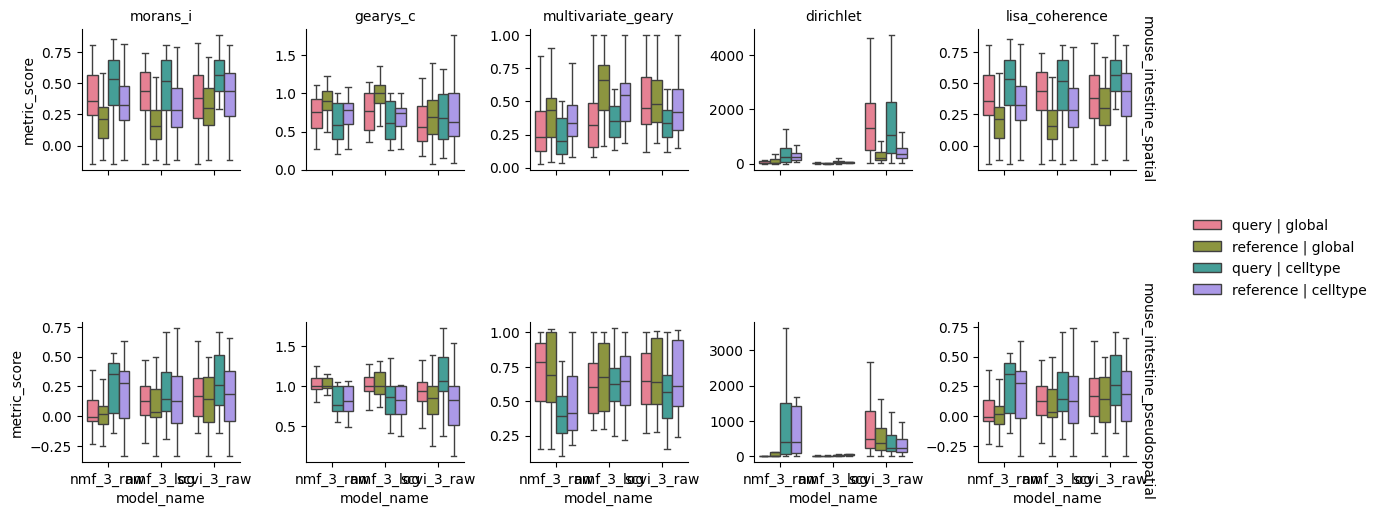

In [ ]:
sns.FacetGrid(
    df,
    col="metric_name",
    row="dataset_name",
    aspect=0.8,
    sharex=True,
    sharey=False,
    margin_titles=True,
).map_dataframe(
    sns.boxplot,
    x="model_name",
    y="metric_score",
    hue="combined_hue",
    palette=sns.color_palette("husl", 4),
    showfliers=False,
).set_titles(row_template="{row_name}", col_template="{col_name}").add_legend()

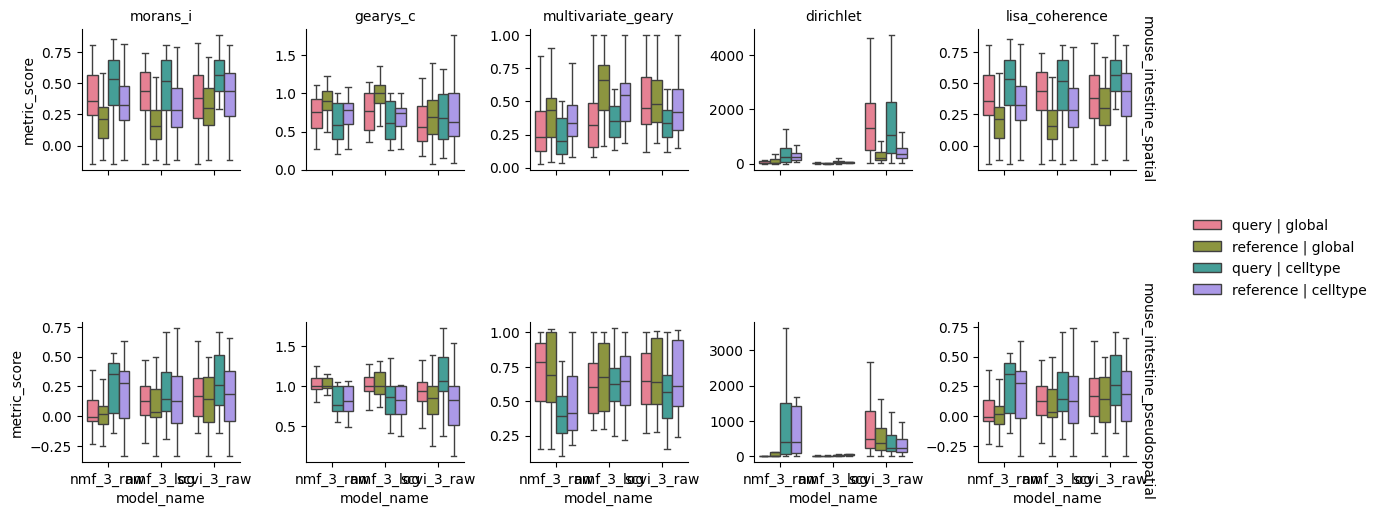

In [ ]:
g = sns.FacetGrid(
    df,
    col="metric_name",
    row="dataset_name",
    aspect=0.8,
    sharex=True,
    sharey=False,
    margin_titles=True,
)
g.map_dataframe(
    sns.boxplot,
    x="model_name",
    y="metric_score",
    hue="combined_hue",
    palette=sns.color_palette("husl", 4),
    showfliers=False,
)
g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.add_legend()